In [ ]:
# ─── Inputs ─────────────────────────────────────────────────
dataset   = "kenya" # kenya, oman
satellite = f"fused_spot_s2_{dataset}"
SATELLITE_PATH        = f'./data/satellite/{satellite}.tif'
TRAINING_GEOJSON_PATH = f'./data/jsons/{dataset}_training_polygons.geojson'
SATELLITE_METADATA_PATH = f'./data/satellite/{satellite}_metadata.json'
# Output — written into the per-region folder so pastors.ipynb reads it from
# the same place (mask_path = ./output/{dataset}/baresoil_mask_{dataset}.tif).
OUTPUT_MASK_PATH      = f'./output/{dataset}/baresoil_mask_{dataset}.tif'

# Class remap + reference class: loaded per-dataset from external JSON
#   ./data/jsons/class_remap_{dataset}.json
#   {"reference_class": int, "remap": {original_id: target_id}}  (1=bare_soil, 2=non_soil)
import json as _json
CLASS_REMAP_PATH = f'./data/jsons/class_remap_{dataset}.json'
with open(CLASS_REMAP_PATH) as _f:
    _cfg = _json.load(_f)
CLASS_REMAP     = {int(k): int(v) for k, v in _cfg['remap'].items()}
REFERENCE_CLASS = int(_cfg['reference_class'])  # all pixels kept; others subsampled to its count
LABEL_COLUMN    = 'label'

# Spectral index bands are resolved from the metadata (eo:bands common_name).

# Google Satellite Embedding (AlphaEarth) - native 10 m, stacked into features
EMB_YEAR = {'oman': 2024, 'kenya': 2025}[dataset]
AOI_PATH = f'./data/geospatial_data_{dataset}/{dataset}_aoi.geojson'   # used only to fetch if missing
EMB_PATH = f'./data/satellite/embeddings_{dataset}.tif'
EMB_INTERPOLATE = True   # embeddings -> True: bilinear 1.5 m, False: nearest 10 m

# Tuning
RANDOM_SEED          = 321     # global seed for reproducibility
USE_OUTLIER_REMOVAL   = True   # set False to skip IsolationForest outlier removal
OUTLIER_CONTAMINATION = 0.05   # per-class IsolationForest outlier fraction
USE_SIEVE             = False  # post-process mask with rasterio sieve (erases small blobs)
SIEVE_MIN_SIZE        = 50     # min blob size (pixels) kept after sieve post-processing
N_TUNING_ITER         = 40     # RandomizedSearchCV iterations

In [2]:
import numpy as np
import rasterio
import geopandas as gpd
from pathlib import Path
from rasterio.features import rasterize

Path(OUTPUT_MASK_PATH).parent.mkdir(parents=True, exist_ok=True)

for p in [SATELLITE_PATH, TRAINING_GEOJSON_PATH]:
    print(f"  {'✓' if Path(p).exists() else '✗'} {p}")

with rasterio.open(SATELLITE_PATH) as src:
    print(f"\nSatellite: {src.count}b  {src.width}x{src.height}  "
          f"CRS={src.crs}  dtype={src.dtypes[0]}")

  ✓ ./data/satellite/fused_spot_s2_kenya.tif
  ✓ ./data/jsons/kenya_training_polygons.geojson

Satellite: 14b  1928x1836  CRS=EPSG:32636  dtype=float32


In [3]:
import os
from helpers.build_feature_stack import build_feature_stack
from helpers.fetch_google_embeddings import fetch_embeddings

if not os.path.exists(EMB_PATH):
    fetch_embeddings(AOI_PATH, EMB_YEAR, EMB_PATH)

# Feature stack kept in memory (not written to disk; recomputed each run)
STACK, FEATURE_NAMES, STACK_META = build_feature_stack(
    SATELLITE_PATH, SATELLITE_METADATA_PATH, out_path=None,
    embeddings_path=EMB_PATH,
    embeddings_resampling=('bilinear' if EMB_INTERPOLATE else 'nearest'),
)
N_BANDS = len(FEATURE_NAMES)
print(f"stack in memory: {STACK.shape}  ({N_BANDS} bands)")

  bands from metadata: {'red': 7, 'green': 6, 'blue': 5, 'nir': 11, 'rededge': 10, 'nir08': 12, 'swir16': 13, 'swir22': 14}
  + 64 embedding bands (bilinear)
  features (85): ['Band_1', 'Band_2', 'Band_3', 'Band_4', 'Band_5', 'Band_6', 'Band_7', 'Band_8', 'Band_9', 'Band_10', 'Band_11', 'Band_12', 'Band_13', 'Band_14', 'NDVI', 'RE_NDVI', 'Blue_Red_Ratio', 'Blue_NIR_Ratio', 'BSI', 'SAVI', 'MSAVI', 'Emb_A00', 'Emb_A01', 'Emb_A02', 'Emb_A03', 'Emb_A04', 'Emb_A05', 'Emb_A06', 'Emb_A07', 'Emb_A08', 'Emb_A09', 'Emb_A10', 'Emb_A11', 'Emb_A12', 'Emb_A13', 'Emb_A14', 'Emb_A15', 'Emb_A16', 'Emb_A17', 'Emb_A18', 'Emb_A19', 'Emb_A20', 'Emb_A21', 'Emb_A22', 'Emb_A23', 'Emb_A24', 'Emb_A25', 'Emb_A26', 'Emb_A27', 'Emb_A28', 'Emb_A29', 'Emb_A30', 'Emb_A31', 'Emb_A32', 'Emb_A33', 'Emb_A34', 'Emb_A35', 'Emb_A36', 'Emb_A37', 'Emb_A38', 'Emb_A39', 'Emb_A40', 'Emb_A41', 'Emb_A42', 'Emb_A43', 'Emb_A44', 'Emb_A45', 'Emb_A46', 'Emb_A47', 'Emb_A48', 'Emb_A49', 'Emb_A50', 'Emb_A51', 'Emb_A52', 'Emb_A53', 'Emb_A

In [4]:
# Load training polygons - keep ORIGINAL multi-class labels (remap at extract)
gdf = gpd.read_file(TRAINING_GEOJSON_PATH)
gdf[LABEL_COLUMN] = gdf[LABEL_COLUMN].astype(int)
print(f"Loaded {len(gdf)} polygons")
print(f"Original labels: {gdf[LABEL_COLUMN].value_counts().sort_index().to_dict()}")

if gdf.crs != STACK_META['crs']:
    gdf = gdf.to_crs(STACK_META['crs'])

Loaded 607 polygons
Original labels: {1: 96, 2: 92, 3: 8, 5: 136, 6: 194, 8: 81}


In [5]:
# Extract pixels: keep ALL pixels of the reference class (vegetation),
# sample every other ORIGINAL class to that same count, then remap to binary.
def extract_training_pixels(stack, transform, gdf, label_col, ref_class, remap):
    H, W = stack.shape[1], stack.shape[2]
    shapes = [(g, int(l)) for g, l in zip(gdf.geometry, gdf[label_col])]
    label_raster = rasterize(shapes, out_shape=(H, W), transform=transform,
                              fill=0, dtype='int32')
    sat_ok = np.abs(stack).sum(axis=0) > 0   # drop fully-zero pixels
    rng = np.random.default_rng(RANDOM_SEED)

    per_class = {}
    for cls in sorted(np.unique(label_raster)):
        if cls == 0:
            continue
        rows, cols = np.where((label_raster == cls) & sat_ok)
        if rows.size == 0:
            print(f"  no pixels for class {cls}"); continue
        Xc = stack[:, rows, cols].T
        Xc = Xc[np.all(np.isfinite(Xc), axis=1)]
        per_class[cls] = Xc

    if ref_class not in per_class:
        raise ValueError(f"Reference class {ref_class} has no usable pixels.")
    target = len(per_class[ref_class])
    print(f"  reference class {ref_class}: {target} px (all kept) -> target for others")

    X_all, y_all = [], []
    for cls, Xc in per_class.items():
        if cls != ref_class and len(Xc) > target:
            Xc = Xc[rng.choice(len(Xc), target, replace=False)]
        print(f"  class {cls}: {len(Xc)} px")
        X_all.append(Xc)
        y_all.append(np.full(len(Xc), cls))

    X = np.vstack(X_all)
    y_orig = np.concatenate(y_all)
    y = np.array([remap[int(v)] for v in y_orig])
    return X, y, y_orig


X, y, y_orig = extract_training_pixels(STACK, STACK_META['transform'], gdf,
                                       LABEL_COLUMN, REFERENCE_CLASS, CLASS_REMAP)
print(f"\nX={X.shape}  binary y counts={dict(zip(*np.unique(y, return_counts=True)))}")

  reference class 6: 32988 px (all kept) -> target for others
  class 1: 32988 px
  class 2: 20573 px
  class 3: 3871 px
  class 5: 2034 px
  class 6: 32988 px
  class 8: 2373 px

X=(94827, 85)  binary y counts={np.int64(1): np.int64(59805), np.int64(2): np.int64(35022)}


=== BEFORE outlier removal ===
Separability (full feature space):
  binary  (1=bare, 2=non-soil): silhouette = +0.264  (n=8000)
  original classes: silhouette = +0.090  (n=8000)

Per original-class mean silhouette (low/negative = overlapping):
  class  1 soil type 1          -> bare     +0.178
  class  2 soil type 2          -> bare     -0.062
  class  3 soil type 3          -> bare     +0.394
  class  5 bushes               -> non-soil +0.189
  class  6 vegetation           -> non-soil +0.064
  class  8 soil type 4          -> bare     +0.103


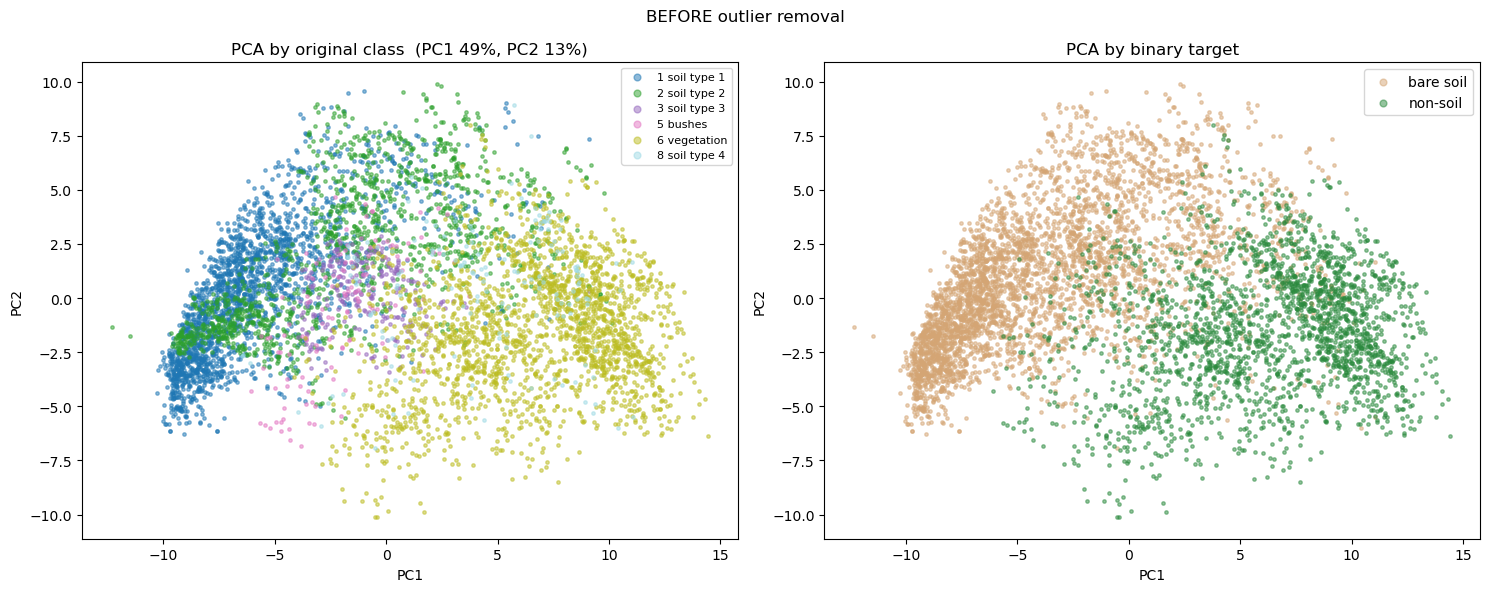

In [6]:
# Cluster / separability check: how well do the classes group in feature space?
# - silhouette score quantifies separability (>0.5 strong, ~0 overlapping, <0 mixed)
# - 2D PCA scatter shows the structure; colour by ORIGINAL class and by BINARY target
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

CLASS_NAMES = {int(k): v for k, v in _cfg.get('class_names', {}).items()}

def separability_report(Xin, y_bin, y_org, title, plot=True):
    """Print silhouette scores (binary, original, per-class) and optionally a 2D PCA scatter."""
    Xs = StandardScaler().fit_transform(Xin)
    rng = np.random.default_rng(RANDOM_SEED)
    sub = lambda n, k: (rng.choice(n, k, replace=False) if n > k else np.arange(n))

    def _sil(labels, name):
        labels = np.asarray(labels)
        if len(np.unique(labels)) < 2:
            print(f"  {name}: <2 classes, skipped"); return
        idx = sub(len(labels), 8000)          # silhouette is O(n^2) -> subsample
        print(f"  {name}: silhouette = {silhouette_score(Xs[idx], labels[idx]):+.3f}  (n={len(idx)})")

    print(f"=== {title} ===")
    print("Separability (full feature space):")
    _sil(y_bin, "binary  (1=bare, 2=non-soil)")
    _sil(y_org, "original classes")

    idxo = sub(len(y_org), 8000)
    svals = silhouette_samples(Xs[idxo], y_org[idxo])
    print("\nPer original-class mean silhouette (low/negative = overlapping):")
    for c in sorted(np.unique(y_org[idxo])):
        m = svals[y_org[idxo] == c].mean()
        tgt = 'bare' if CLASS_REMAP[int(c)] == 1 else 'non-soil'
        print(f"  class {int(c):>2} {CLASS_NAMES.get(int(c),''):<20} -> {tgt:<8} {m:+.3f}")

    if not plot:
        print(); return
    proj = PCA(n_components=2, random_state=RANDOM_SEED).fit(Xs)
    P, ev = proj.transform(Xs), proj.explained_variance_ratio_ * 100
    pidx = sub(len(P), 6000)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    classes = sorted(np.unique(y_org))
    cmap = plt.cm.tab20(np.linspace(0, 1, len(classes)))
    for i, c in enumerate(classes):
        m = y_org[pidx] == c
        axes[0].scatter(P[pidx][m, 0], P[pidx][m, 1], s=6, alpha=0.5,
                        color=cmap[i], label=f"{int(c)} {CLASS_NAMES.get(int(c),'')}")
    axes[0].set_title(f"PCA by original class  (PC1 {ev[0]:.0f}%, PC2 {ev[1]:.0f}%)")
    axes[0].legend(markerscale=2, fontsize=8, loc='best')
    bcol, bname = {1: '#D4A574', 2: '#2B8A3E'}, {1: 'bare soil', 2: 'non-soil'}
    for b in (1, 2):
        m = y_bin[pidx] == b
        axes[1].scatter(P[pidx][m, 0], P[pidx][m, 1], s=6, alpha=0.5, color=bcol[b], label=bname[b])
    axes[1].set_title("PCA by binary target")
    axes[1].legend(markerscale=2)
    for ax in axes:
        ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

separability_report(X, y, y_orig, "BEFORE outlier removal")


Outlier removal (IsolationForest, contamination=0.05):
  class 1: 32988 px -> dropped 1650 (5.0%)
  class 2: 20573 px -> dropped 1029 (5.0%)
  class 3: 3871 px -> dropped 194 (5.0%)
  class 5: 2034 px -> dropped 102 (5.0%)
  class 6: 32988 px -> dropped 1650 (5.0%)
  class 8: 2373 px -> dropped 119 (5.0%)
  total kept: 90083 / 94827
After cleaning: X=(90083, 85)  binary y counts={np.int64(1): np.int64(56813), np.int64(2): np.int64(33270)}
=== AFTER outlier removal ===
Separability (full feature space):
  binary  (1=bare, 2=non-soil): silhouette = +0.289  (n=8000)
  original classes: silhouette = +0.107  (n=8000)

Per original-class mean silhouette (low/negative = overlapping):
  class  1 soil type 1          -> bare     +0.224
  class  2 soil type 2          -> bare     -0.063
  class  3 soil type 3          -> bare     +0.408
  class  5 bushes               -> non-soil +0.203
  class  6 vegetation           -> non-soil +0.064
  class  8 soil type 4          -> bare     +0.147


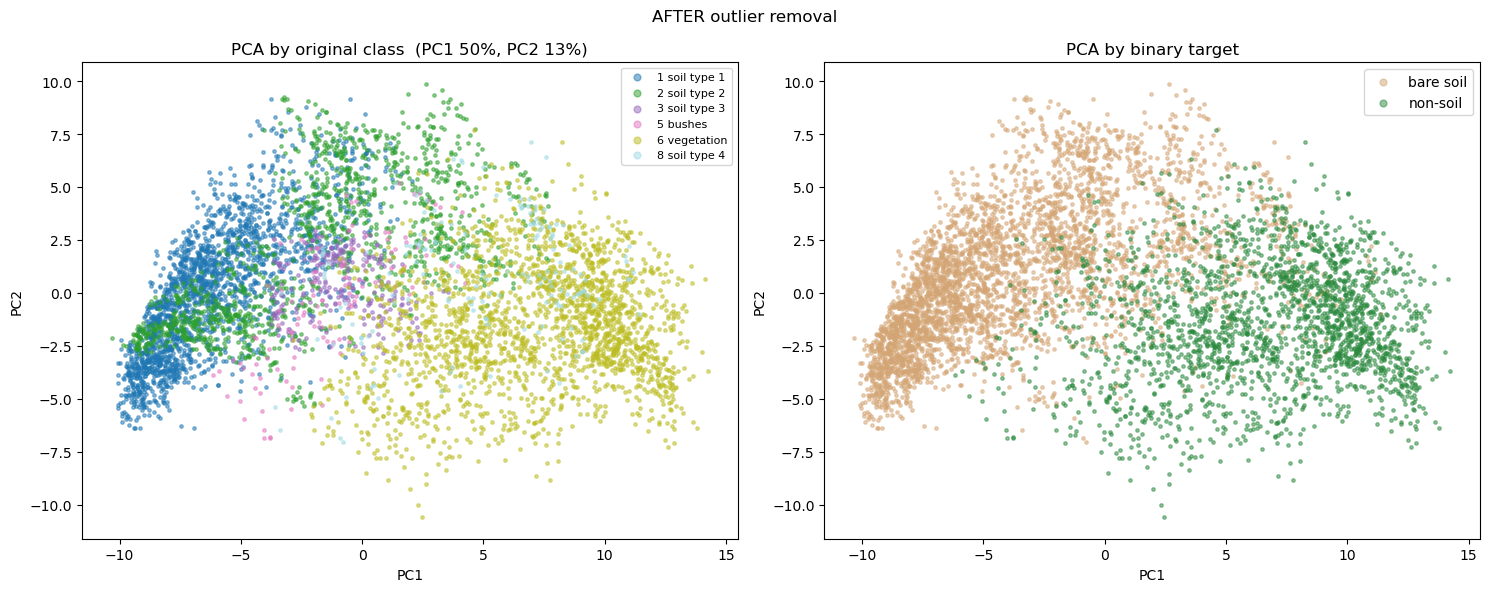

In [7]:
# Per-class outlier removal (IsolationForest) before training - optional.
# Run on ORIGINAL classes (y_orig) so each true class's bulk is modelled, then
# carry the keep-mask to all arrays. Cleaning per real class tightens the groups
# far more than cleaning the two merged binary blobs.
from helpers.outlier_removal import remove_outliers_per_class

if USE_OUTLIER_REMOVAL:
    _, _, keep = remove_outliers_per_class(X, y_orig, contamination=OUTLIER_CONTAMINATION,
                                           random_state=RANDOM_SEED)
    X, y, y_orig = X[keep], y[keep], y_orig[keep]
    print(f"After cleaning: X={X.shape}  binary y counts={dict(zip(*np.unique(y, return_counts=True)))}")
    separability_report(X, y, y_orig, "AFTER outlier removal")
else:
    print("Outlier removal skipped (USE_OUTLIER_REMOVAL=False)")


In [8]:
# Train with RandomizedSearchCV over an expanded grid (global seed).
from xgboost import XGBClassifier
from sklearn.model_selection import (StratifiedKFold, RandomizedSearchCV,
                                     cross_val_predict)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

encoder = {c: i for i, c in enumerate(sorted(np.unique(y)))}
decoder = {i: c for c, i in encoder.items()}
y_enc   = np.array([encoder[v] for v in y])
sw      = compute_sample_weight('balanced', y_enc)

param_dist = {
    'n_estimators':     [700, 900, 1100, 1300],
    'max_depth':        [3, 4, 5, 6, 8, 10],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.5],
    'reg_alpha':        [0, 0.1, 1.0],
    'reg_lambda':       [1.0, 2.0, 5.0],
}

base = XGBClassifier(objective='multi:softmax', num_class=len(encoder),
                     tree_method='hist', n_jobs=-1, random_state=RANDOM_SEED,
                     verbosity=0)
search = RandomizedSearchCV(
    base, param_distributions=param_dist, n_iter=N_TUNING_ITER,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_weighted', random_state=RANDOM_SEED, n_jobs=-1, verbose=1,
)
search.fit(X, y_enc, sample_weight=sw)
print(f'Best CV F1: {search.best_score_:.4f}  params={search.best_params_}')

clf = XGBClassifier(**search.best_params_, objective='multi:softmax',
                    num_class=len(encoder), tree_method='hist', n_jobs=-1,
                    random_state=RANDOM_SEED, verbosity=0)

# Sanity CV report (pixel-level CV is spatially optimistic, not the goal)
y_cv = cross_val_predict(
    clf, X, y_enc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
)
y_cv = np.array([decoder[v] for v in y_cv])
print(classification_report(y, y_cv))
print('Confusion:\n', confusion_matrix(y, y_cv))

clf.fit(X, y_enc, sample_weight=sw)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best CV F1: 0.9981  params={'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 1300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     56813
           2       1.00      1.00      1.00     33270

    accuracy                           1.00     90083
   macro avg       1.00      1.00      1.00     90083
weighted avg       1.00      1.00      1.00     90083

Confusion:
 [[56764    49]
 [   80 33190]]


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.6
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=

In [9]:
# Predict mask in row-chunks from the in-memory stack
def predict_mask(stack, meta, classifier, decoder, out_path, chunk=1024):
    H, W = stack.shape[1], stack.shape[2]
    nb   = stack.shape[0]
    out_meta = meta.copy()
    out_meta.update(count=1, dtype='uint8', nodata=0, compress='lzw')

    with rasterio.open(out_path, 'w', **out_meta) as dst:
        counts, total = {}, 0
        for r0 in range(0, H, chunk):
            r1 = min(r0 + chunk, H)
            px = stack[:, r0:r1, :].reshape(nb, -1).T
            valid = np.all(np.isfinite(px), axis=1)
            valid &= np.abs(px).sum(axis=1) > 0
            pred = np.zeros(px.shape[0], dtype=np.uint8)
            if valid.sum():
                enc = classifier.predict(px[valid])
                pred[valid] = np.array([decoder[int(v)] for v in enc], dtype=np.uint8)
            dst.write(pred.reshape(r1 - r0, W), 1,
                      window=rasterio.windows.Window(0, r0, W, r1 - r0))
            total += int(valid.sum())
            for c in np.unique(pred[valid]):
                counts[int(c)] = counts.get(int(c), 0) + int((pred[valid] == c).sum())

    print(f"\n✓ {out_path}")
    for c in sorted(counts):
        print(f"    class {c}: {counts[c]:,}  ({counts[c]/total*100:.1f}%)")


predict_mask(STACK, STACK_META, clf, decoder, OUTPUT_MASK_PATH)


✓ ./output/baresoil_mask_kenya.tif
    class 1: 2,001,898  (78.9%)
    class 2: 535,853  (21.1%)


In [10]:
# Post-process: remove small speckle blobs with rasterio sieve (optional)
from helpers.sieve_mask import sieve_mask

if USE_SIEVE:
    sieve_mask(OUTPUT_MASK_PATH, min_size=SIEVE_MIN_SIZE, connectivity=4)
else:
    print('Sieve skipped (USE_SIEVE=False) - raw per-pixel mask kept')

Sieve skipped (USE_SIEVE=False) - raw per-pixel mask kept


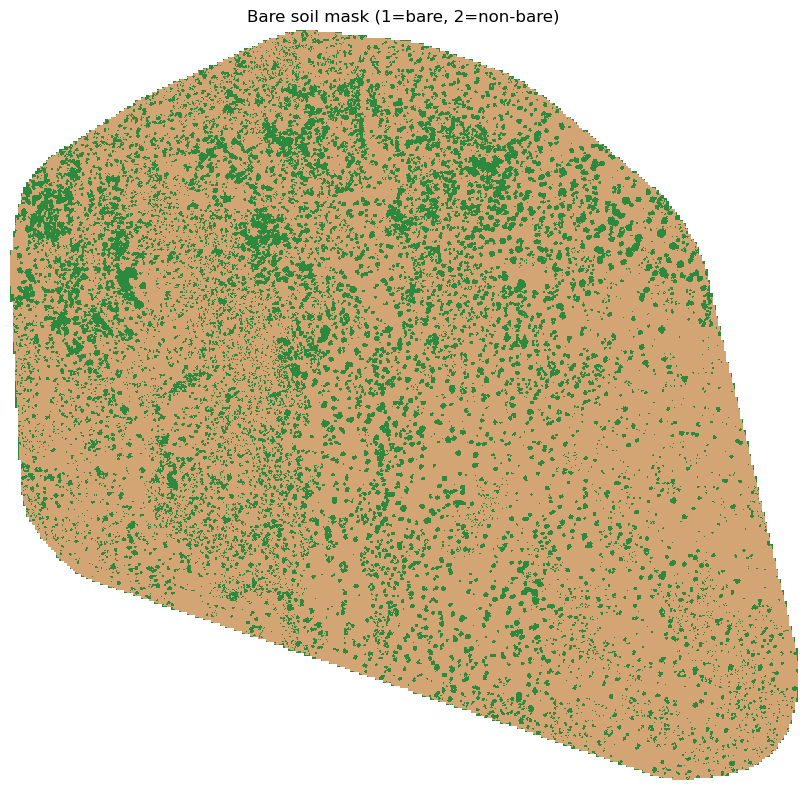

In [11]:
# Visual check
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

with rasterio.open(OUTPUT_MASK_PATH) as src:
    mask = src.read(1)

fig, ax = plt.subplots(figsize=(10, 8))
cmap = ListedColormap(['#D4A574', '#2B8A3E'])
disp = np.ma.masked_where(mask == 0, mask)
ax.imshow(disp, cmap=cmap, vmin=1, vmax=2, interpolation='nearest')
ax.set_title('Bare soil mask (1=bare, 2=non-bare)')
ax.axis('off')
plt.tight_layout()
plt.show()